# 06 — Evaluasi Model Mendalam (LightGBM)

Notebook ini melakukan **deep evaluation** terhadap model LightGBM yang telah dilatih di `05_modelling.ipynb`.

**Prasyarat:** jalankan `05_modelling.ipynb` terlebih dahulu untuk menghasilkan:
- `models/lightgbm_model.pkl`
- `data/processed/X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv`
- `artifacts/robust_scaler.pkl`, `artifacts/feature_list.json`, `artifacts/label_encoder_city.pkl`

---
## 1. Setup & Load Artifacts

In [1]:
# === SEL INISIALISASI ===
import pandas as pd
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import joblib, json, os
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
import lightgbm as lgb

sns.set_theme(style='whitegrid', palette='muted')

# === Load artefak dari nb04 & nb05 ===
X_train = pd.read_csv('data/processed/X_train.csv')
X_test  = pd.read_csv('data/processed/X_test.csv')
y_train = pd.read_csv('data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('data/processed/y_test.csv').squeeze()

scaler      = joblib.load('artifacts/robust_scaler.pkl')
le_city     = joblib.load('artifacts/label_encoder_city.pkl')
with open('artifacts/feature_list.json') as f:
    FEATURES = json.load(f)

lgb_model   = joblib.load('models/lightgbm_model.pkl')

df_test_dt  = pd.read_csv('data/processed/df_test_datetime.csv')
df_test_dt['datetime'] = pd.to_datetime(df_test_dt['datetime'])

y_pred_lgb  = lgb_model.predict(X_test)

print(f"LightGBM model loaded — best_iteration: {lgb_model.best_iteration_}")
print(f"Train shape : {X_train.shape}")
print(f"Test shape  : {X_test.shape}")

LightGBM model loaded — best_iteration: 308
Train shape : (837697, 98)
Test shape  : (209438, 98)


---
## 2. Regenerasi Prediksi & Tabel Metrik Lengkap

In [2]:
def evaluate(y_true, y_pred, model_name):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    return {'Model': model_name, 'MAE': round(mae,4), 'RMSE': round(rmse,4),
            'R2': round(r2,4), 'MAPE': round(mape,4)}

y_arr = y_test.values

# Baseline Naive
naive_pred_all   = X_test['aqi_lag1'].values

# Baseline Rolling Mean
rolling_pred_all = X_test['aqi_roll24m'].values

# Buat common_mask: baris valid untuk SEMUA model agar evaluasi apple-to-apple.
# Beberapa baris paling awal per kota mungkin NaN pada lag/rolling features.
common_mask = ~np.isnan(naive_pred_all) & ~np.isnan(rolling_pred_all)
n_excluded  = (~common_mask).sum()
print(f"Baris dikecualikan (NaN lag/rolling): {n_excluded:,} dari {len(common_mask):,}")

naive_pred   = naive_pred_all[common_mask]
rolling_pred = rolling_pred_all[common_mask]
y_eval       = y_arr[common_mask]   # subset yang sama untuk semua model

# LightGBM — prediksi pada seluruh test set, evaluasi pada common subset
y_pred_lgb = lgb_model.predict(X_test)

records = [
    evaluate(y_eval, naive_pred,            'Baseline Naive'),
    evaluate(y_eval, rolling_pred,          'Baseline Rolling Mean (24h)'),
    evaluate(y_eval, y_pred_lgb[common_mask], 'LightGBM'),
]
df_metrics = pd.DataFrame(records)

print('=== TABEL METRIK KOMPARATIF (subset yang sama, apple-to-apple) ===')
display(
    df_metrics.style
    .highlight_min(subset=['MAE','RMSE','MAPE'], color='#c8f7c5')
    .highlight_max(subset=['R2'],                color='#c8f7c5')
    .format({'MAE':'{:.2f}','RMSE':'{:.2f}','R2':'{:.4f}','MAPE':'{:.2f}%'})
)

df_metrics.to_csv('results/metrics_comparison.csv', index=False)
print('Disimpan: results/metrics_comparison.csv')

Baris dikecualikan (NaN lag/rolling): 0 dari 209,438


=== TABEL METRIK KOMPARATIF (subset yang sama, apple-to-apple) ===


,Model,MAE,RMSE,R2,MAPE
0,Baseline Naive,1.25,2.79,0.9965,1.37%
1,Baseline Rolling Mean (24h),8.59,12.40,0.9305,10.04%
2,LightGBM,1.13,1.77,0.9986,1.29%


Disimpan: results/metrics_comparison.csv


### 2b. Mengapa Baseline Naive Kompetitif? — Analisis Autokorelasi AQI

Plot ACF (Autocorrelation Function) menunjukkan seberapa kuat AQI per jam di satu kota berkorelasi dengan nilai jam-jam sebelumnya. Jika lag-1 autocorrelation tinggi (mendekati 1.0), prediksi sederhana  sudah hampir tepat — itulah yang Baseline Naive lakukan menggunakan fitur .

> **Catatan metodologi:** Analisis dilakukan pada data satu kota (Dhaka) agar autocorrelation yang terukur mencerminkan persistensi temporal yang sebenarnya, bukan artefak dari pengurutan global multi-city (di mana baris berurutan bisa berasal dari kota yang berbeda).

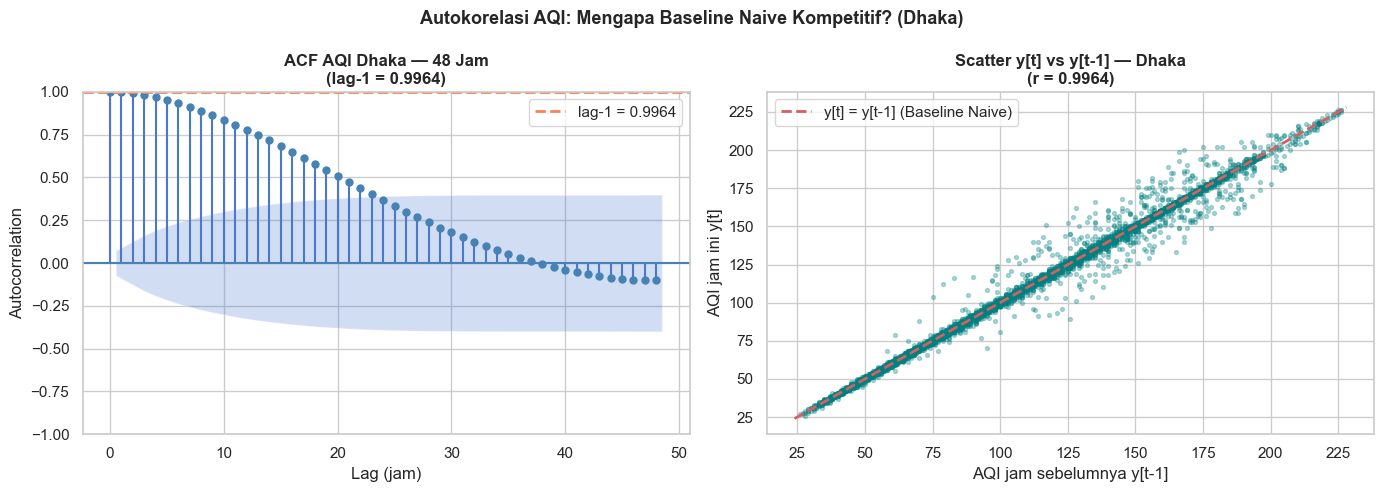

Lag-1 Autocorrelation AQI (Dhaka)  : 0.9964
Lag-24 Autocorrelation AQI (Dhaka) : 0.8996

  - Lag-1 autocorrelation Dhaka: 1.00 — AQI jam ini sangat persisten dengan jam sebelumnya
  - Baseline Naive MAE=1.25 vs LightGBM MAE=1.13
  - LightGBM unggul di RMSE karena menangani spike AQI lebih baik dari prediksi naif


In [3]:
from statsmodels.graphics.tsaplots import plot_acf

# Autocorrelation harus dihitung PER KOTA, bukan pada data global multi-city.
# y_test diurutkan secara global (semua kota pada timestamp yang sama berurutan),
# sehingga baris berurutan bisa berasal dari kota berbeda → lag-1 global mendekati 0.
# Kita unscale city_encoded untuk memfilter ke satu kota representatif (Dhaka).
scaler_acf = joblib.load('artifacts/robust_scaler.pkl')
_scale_cols = list(scaler_acf.feature_names_in_)
_city_idx   = _scale_cols.index('city_encoded')
_center     = scaler_acf.center_[_city_idx]
_scale      = scaler_acf.scale_[_city_idx]
unscaled_city_acf = np.round(X_test['city_encoded'].values * _scale + _center).astype(int)

dhaka_mask  = (unscaled_city_acf == 21)   # Dhaka = city_encoded 21
aqi_series  = y_test.values[dhaka_mask]   # ~7000 jam data Dhaka

lag1_autocorr  = pd.Series(aqi_series).autocorr(lag=1)
lag24_autocorr = pd.Series(aqi_series).autocorr(lag=24)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Autokorelasi AQI: Mengapa Baseline Naive Kompetitif? (Dhaka)',
             fontsize=13, fontweight='bold')

plot_acf(aqi_series[:720], lags=48, ax=axes[0], color='steelblue', alpha=0.05)
axes[0].set_title(f'ACF AQI Dhaka — 48 Jam\n(lag-1 = {lag1_autocorr:.4f})', fontweight='bold')
axes[0].set_xlabel('Lag (jam)')
axes[0].set_ylabel('Autocorrelation')
axes[0].axhline(lag1_autocorr, color='coral', linestyle='--', linewidth=2,
                label=f'lag-1 = {lag1_autocorr:.4f}')
axes[0].legend()

y_arr_sub  = aqi_series[1:]
y_lag1_sub = aqi_series[:-1]
axes[1].scatter(y_lag1_sub, y_arr_sub, alpha=0.3, s=8, color='teal')
lim = [min(y_lag1_sub.min(), y_arr_sub.min()) - 2,
       max(y_lag1_sub.max(), y_arr_sub.max()) + 2]
axes[1].plot(lim, lim, 'r--', linewidth=2, label='y[t] = y[t-1] (Baseline Naive)')
axes[1].set_xlabel('AQI jam sebelumnya y[t-1]')
axes[1].set_ylabel('AQI jam ini y[t]')
axes[1].set_title(f'Scatter y[t] vs y[t-1] — Dhaka\n(r = {lag1_autocorr:.4f})', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('results/plots/aqi_autocorrelation.png', dpi=120)
plt.show()

print(f'Lag-1 Autocorrelation AQI (Dhaka)  : {lag1_autocorr:.4f}')
print(f'Lag-24 Autocorrelation AQI (Dhaka) : {lag24_autocorr:.4f}')
print()
lgb_mae   = df_metrics[df_metrics["Model"]=="LightGBM"]["MAE"].values[0]
naive_mae = df_metrics[df_metrics["Model"]=="Baseline Naive"]["MAE"].values[0]
print(f'  - Lag-1 autocorrelation Dhaka: {lag1_autocorr:.2f} — AQI jam ini sangat persisten dengan jam sebelumnya')
print(f'  - Baseline Naive MAE={naive_mae:.2f} vs LightGBM MAE={lgb_mae:.2f}')
print(f'  - LightGBM unggul di RMSE karena menangani spike AQI lebih baik dari prediksi naif')

---
## 3. Feature Importance

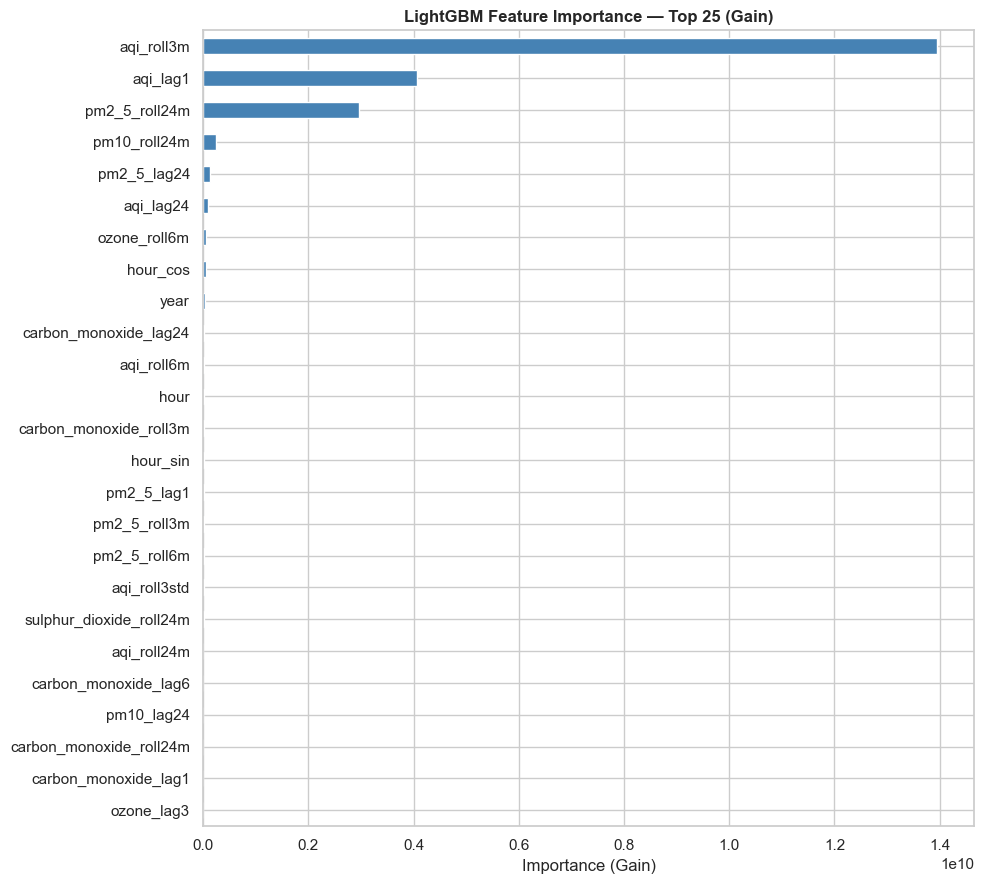

Top 5 fitur: ['aqi_roll3m', 'aqi_lag1', 'pm2_5_roll24m', 'pm10_roll24m', 'pm2_5_lag24']


In [4]:
# LightGBM feature importance — gain-based (kontribusi rata-rata tiap split)
gain_imp = lgb_model.booster_.feature_importance(importance_type='gain')
importances = pd.Series(gain_imp, index=FEATURES).sort_values(ascending=False)

top_n = 25
fig, ax = plt.subplots(figsize=(10, 9))
importances.head(top_n).sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title(f'LightGBM Feature Importance — Top {top_n} (Gain)', fontweight='bold')
ax.set_xlabel('Importance (Gain)')
plt.tight_layout()
os.makedirs('results/plots', exist_ok=True)
plt.savefig('results/plots/feature_importance_lgb.png', dpi=120)
plt.show()

importances.reset_index().rename(columns={'index':'feature', 0:'importance'}).to_csv(
    'results/feature_importance.csv', index=False
)
print(f"Top 5 fitur: {importances.head(5).index.tolist()}")

---
## 3b. SHAP Values — Per-Prediction Interpretability

SHAP (SHapley Additive exPlanations) memberi nilai kontribusi fitur **per prediksi**, bukan hanya rata-rata global. Ini mengungkap bagaimana model membuat keputusan untuk setiap baris data.

> **Catatan komputasi:** TreeExplainer dijalankan pada subsample 2.000 baris dari X_test agar waktu kalkulasi < 2 menit.

C:\Users\faizn\projects\daming-kelompok-7\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


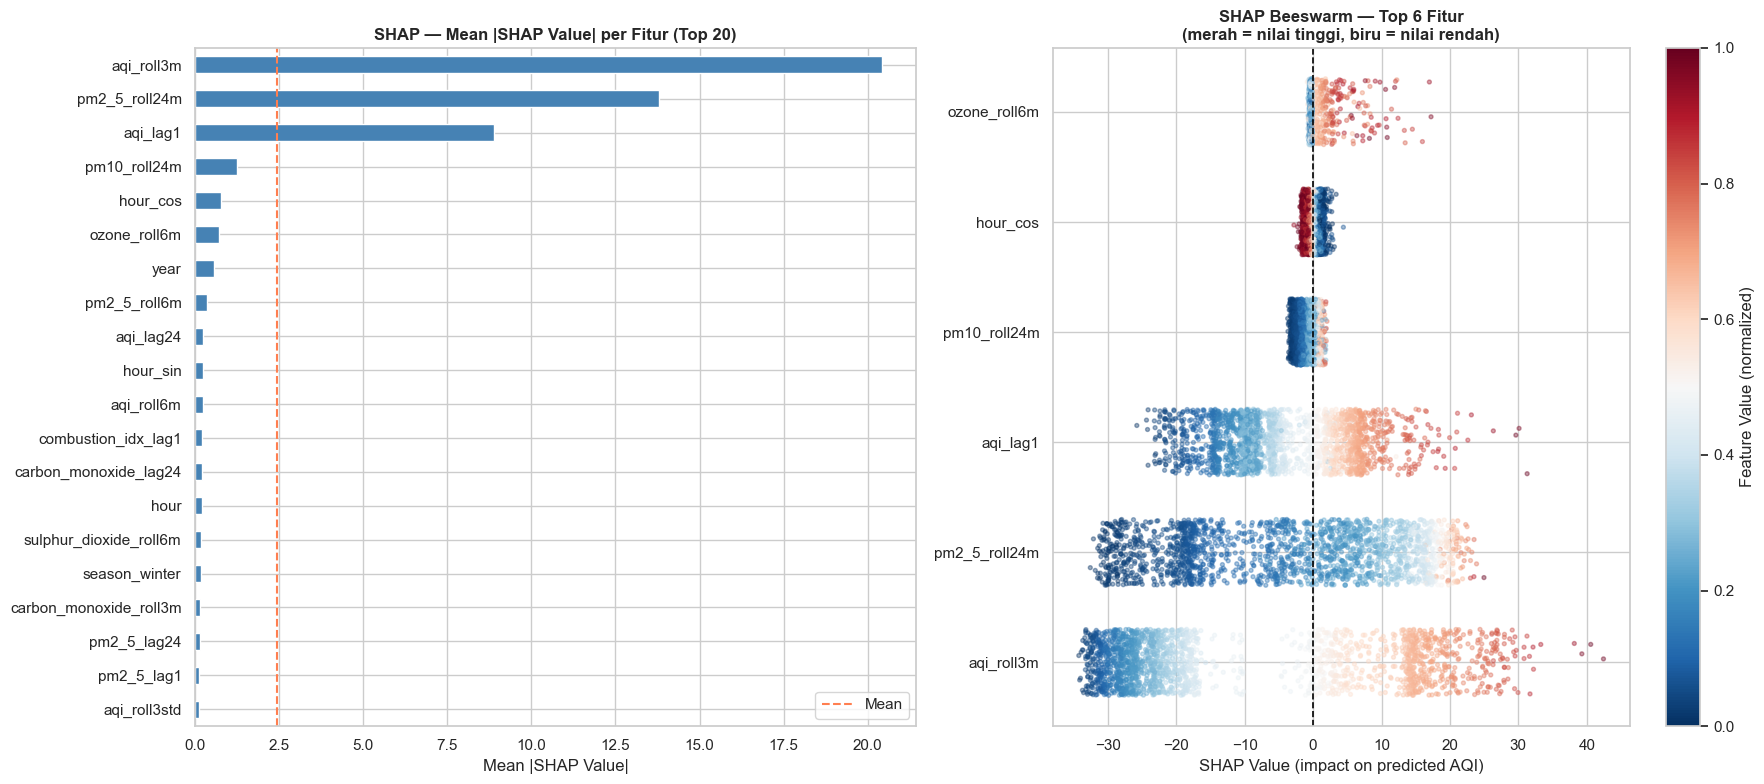

Top 5 fitur (SHAP): ['aqi_roll3m', 'pm2_5_roll24m', 'aqi_lag1', 'pm10_roll24m', 'hour_cos']


In [5]:
try:
    import shap

    SHAP_SAMPLE = 2000
    np.random.seed(42)
    shap_idx = np.random.choice(len(X_test), SHAP_SAMPLE, replace=False)
    X_shap = X_test.iloc[shap_idx]

    explainer   = shap.TreeExplainer(lgb_model)
    shap_values = explainer.shap_values(X_shap)

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    shap_mean_abs = pd.Series(
        np.abs(shap_values).mean(axis=0), index=X_test.columns
    ).sort_values(ascending=False)

    shap_mean_abs.head(20)[::-1].plot(
        kind='barh', ax=axes[0], color='steelblue', edgecolor='white'
    )
    axes[0].set_title('SHAP — Mean |SHAP Value| per Fitur (Top 20)', fontweight='bold')
    axes[0].set_xlabel('Mean |SHAP Value|')
    axes[0].axvline(shap_mean_abs.head(20).mean(), color='coral', linestyle='--',
                    linewidth=1.5, label='Mean')
    axes[0].legend()

    top6 = shap_mean_abs.head(6).index.tolist()
    for i, feat in enumerate(top6):
        feat_idx  = list(X_test.columns).index(feat)
        feat_vals = X_shap[feat].values
        shap_vals = shap_values[:, feat_idx]
        norm = plt.Normalize(feat_vals.min(), feat_vals.max())
        c    = plt.cm.RdBu_r(norm(feat_vals))
        axes[1].scatter(
            shap_vals,
            np.full_like(shap_vals, i) + np.random.uniform(-0.3, 0.3, len(shap_vals)),
            c=c, alpha=0.4, s=8
        )

    axes[1].set_yticks(range(len(top6)))
    axes[1].set_yticklabels(top6)
    axes[1].axvline(0, color='black', linestyle='--', linewidth=1.2)
    axes[1].set_xlabel('SHAP Value (impact on predicted AQI)')
    axes[1].set_title('SHAP Beeswarm — Top 6 Fitur\n(merah = nilai tinggi, biru = nilai rendah)',
                      fontweight='bold')
    sm = plt.cm.ScalarMappable(cmap='RdBu_r'); sm.set_array([])
    plt.colorbar(sm, ax=axes[1], label='Feature Value (normalized)')

    plt.tight_layout()
    plt.savefig('results/plots/shap_analysis.png', dpi=120)
    plt.show()

    shap_df = shap_mean_abs.reset_index()
    shap_df.columns = ['feature', 'mean_abs_shap']
    shap_df.to_csv('results/shap_importance.csv', index=False)
    print(f'Top 5 fitur (SHAP): {shap_df.head(5)["feature"].tolist()}')

except ImportError:
    print("shap tidak terinstal. Jalankan: pip install 'shap>=0.42,<1.0'")

---
## 4. Residual Analysis

Empat diagnostik plot untuk menilai kualitas model:
1. **Distribusi residual** — idealnya normal, centered di 0
2. **Residual vs Waktu** — tidak boleh ada pola sistematis
3. **Residual vs Prediksi** — tidak boleh membesar seiring prediksi (homoskedastisitas)
4. **Q-Q Plot** — normalitas residual

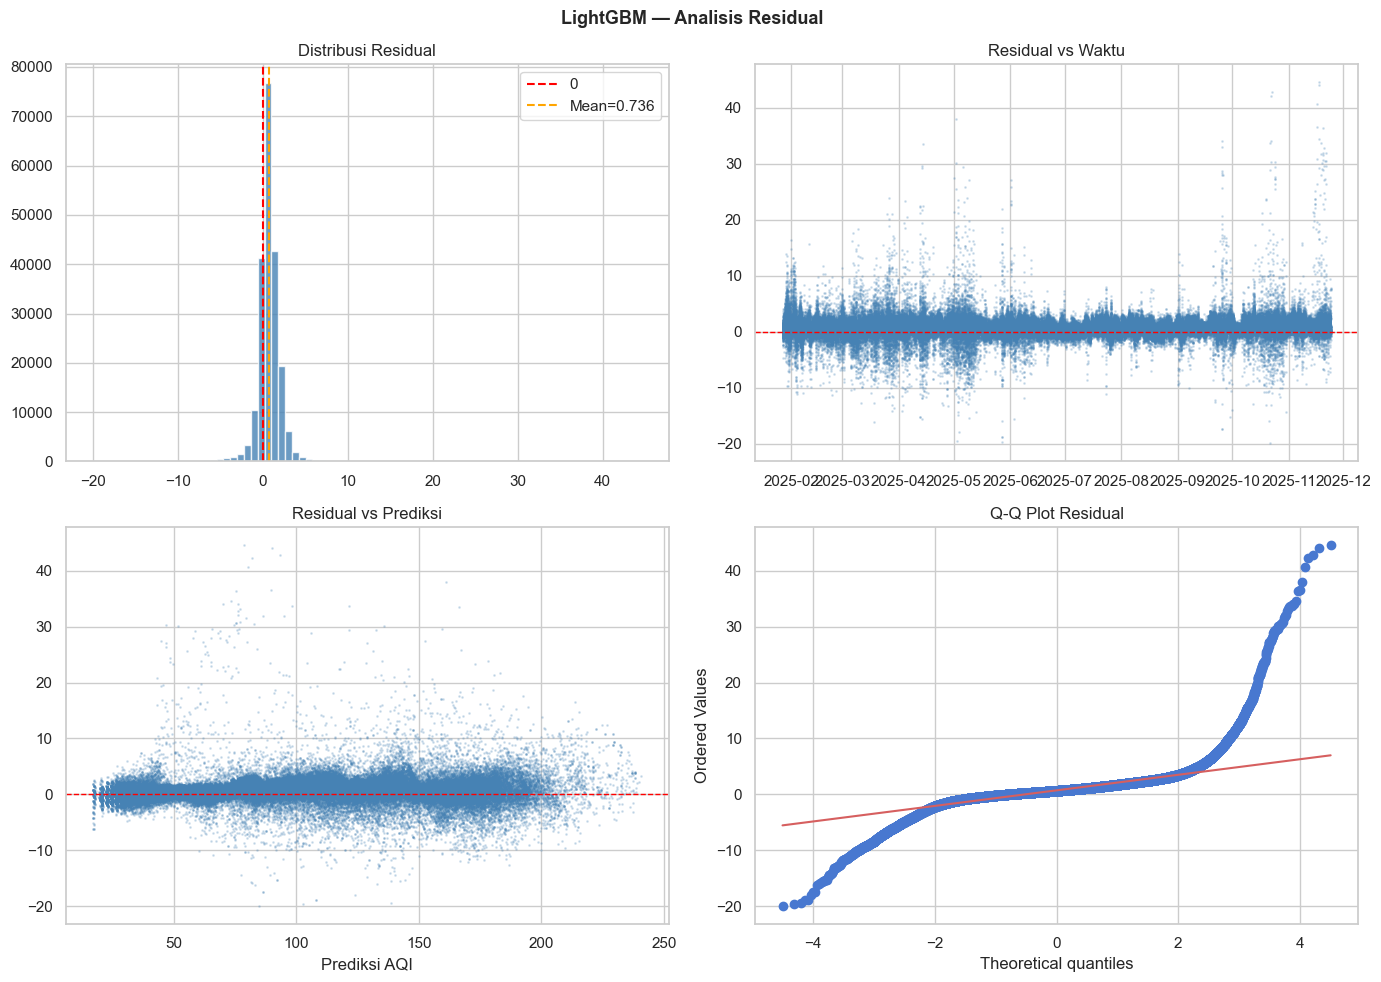

In [6]:
residuals  = y_test.values - y_pred_lgb
test_dates = df_test_dt['datetime'].values

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogram residual
axes[0,0].hist(residuals, bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[0,0].axvline(0, color='red', linewidth=1.5, linestyle='--', label='0')
axes[0,0].axvline(residuals.mean(), color='orange', linewidth=1.5, linestyle='--',
                  label=f'Mean={residuals.mean():.3f}')
axes[0,0].set_title('Distribusi Residual'); axes[0,0].legend()

# 2. Residual vs Waktu
axes[0,1].scatter(test_dates, residuals, s=1, alpha=0.2, color='steelblue')
axes[0,1].axhline(0, color='red', linewidth=1, linestyle='--')
axes[0,1].set_title('Residual vs Waktu')

# 3. Residual vs Prediksi (homoskedasticity check)
axes[1,0].scatter(y_pred_lgb, residuals, s=1, alpha=0.2, color='steelblue')
axes[1,0].axhline(0, color='red', linewidth=1, linestyle='--')
axes[1,0].set_title('Residual vs Prediksi'); axes[1,0].set_xlabel('Prediksi AQI')

# 4. Q-Q Plot
from scipy import stats
stats.probplot(residuals, plot=axes[1,1])
axes[1,1].set_title('Q-Q Plot Residual')

plt.suptitle('LightGBM — Analisis Residual', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('results/plots/residual_analysis.png', dpi=120)
plt.show()

---
## 5. Per-City Performance Breakdown

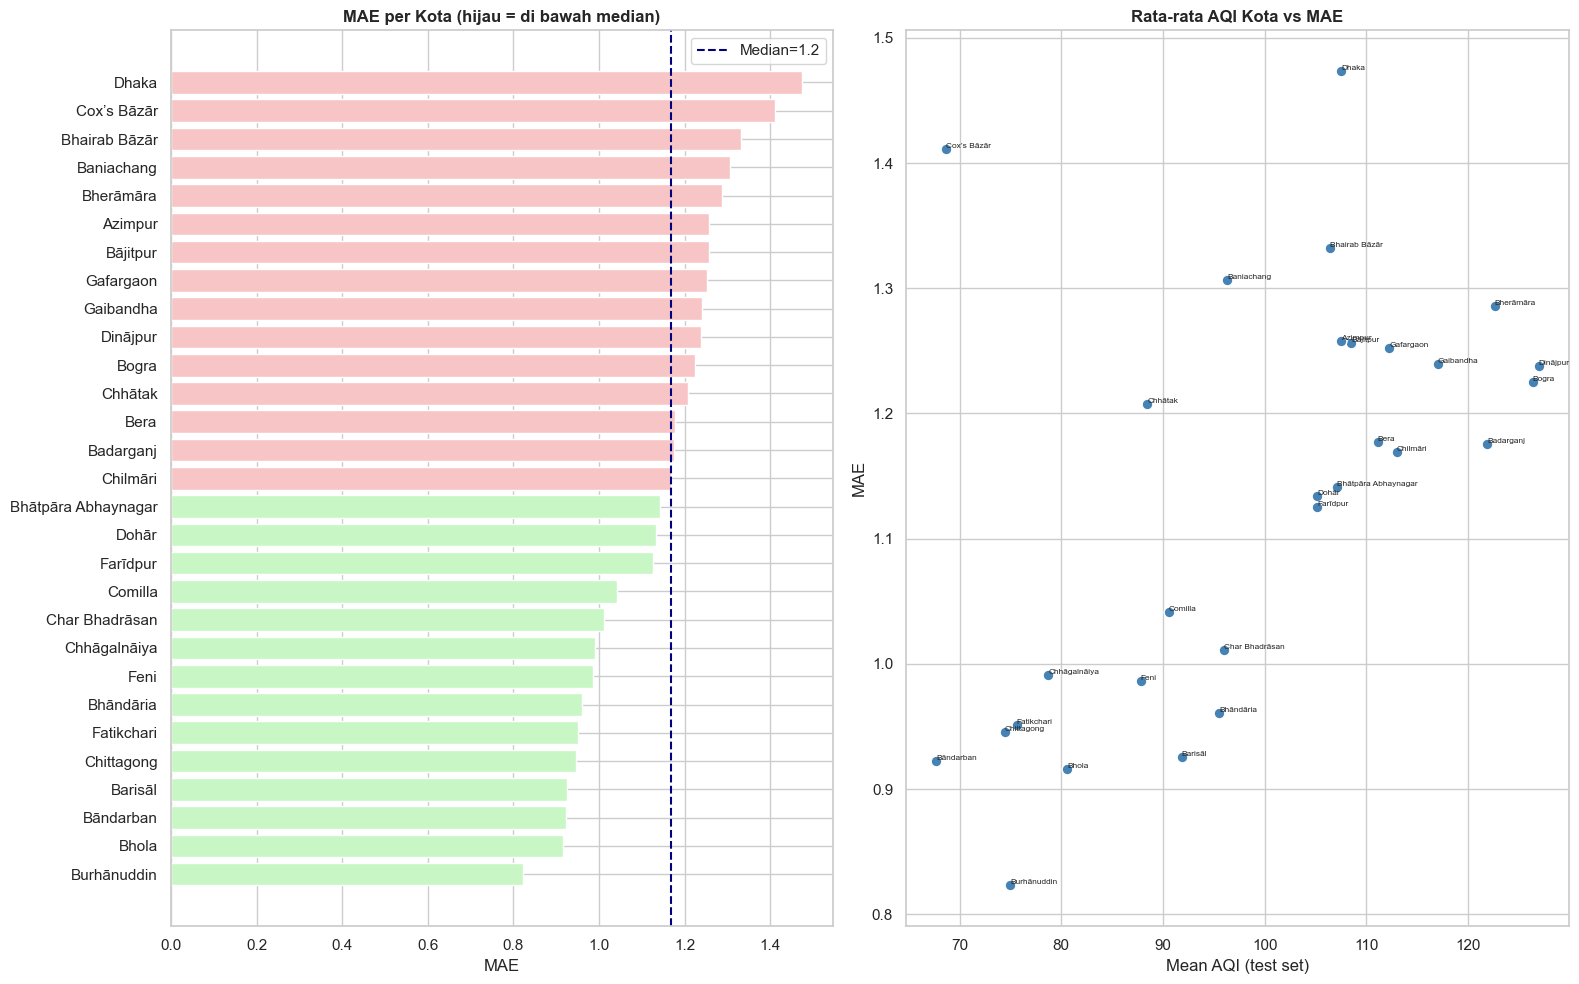


5 Kota Terbaik (MAE terendah):
  city_name      MAE     RMSE       R2  Mean_AQI
Burhānuddin 0.823020 1.205103 0.999186 75.000692
      Bhola 0.916246 1.279580 0.999141 80.585433
  Bāndarban 0.922708 1.337261 0.999105 67.712545
    Barisāl 0.925256 1.257873 0.999197 91.827333
 Chittagong 0.945965 1.345237 0.998933 74.430629

5 Kota Terburuk (MAE tertinggi):
    city_name      MAE     RMSE       R2   Mean_AQI
    Bherāmāra 1.286028 1.840078 0.998260 122.622819
   Baniachang 1.306921 2.212423 0.997678  96.331349
Bhairab Bāzār 1.331895 2.156199 0.997910 106.426336
  Cox’s Bāzār 1.410900 3.477403 0.993757  68.630850
        Dhaka 1.473358 2.886735 0.996111 107.513154


In [7]:
df_eval = X_test[['city_encoded']].copy()
df_eval['y_true'] = y_test.values
df_eval['y_pred'] = y_pred_lgb
df_eval['residual'] = df_eval['y_true'] - df_eval['y_pred']

scaler_obj  = joblib.load('artifacts/robust_scaler.pkl')
scale_cols  = list(scaler_obj.feature_names_in_)
city_idx    = scale_cols.index('city_encoded')
center      = scaler_obj.center_[city_idx]
scale       = scaler_obj.scale_[city_idx]
unscaled_city = np.round(df_eval['city_encoded'] * scale + center).astype(int)
df_eval['city_name'] = le_city.inverse_transform(unscaled_city)

def city_metrics(g):
    return pd.Series({
        'MAE' : mean_absolute_error(g['y_true'], g['y_pred']),
        'RMSE': np.sqrt(mean_squared_error(g['y_true'], g['y_pred'])),
        'R2'  : r2_score(g['y_true'], g['y_pred']),
        'Mean_AQI': g['y_true'].mean(),
        'n_samples': len(g),
    })

city_perf = df_eval.groupby('city_name').apply(city_metrics, include_groups=False).reset_index()
city_perf = city_perf.sort_values('MAE')

fig, axes = plt.subplots(1, 2, figsize=(16, 10))

colors_mae = ['#c8f7c5' if x < city_perf['MAE'].median() else '#f7c5c5' for x in city_perf['MAE']]
axes[0].barh(city_perf['city_name'], city_perf['MAE'], color=colors_mae, edgecolor='white')
axes[0].axvline(city_perf['MAE'].median(), color='navy', linestyle='--', linewidth=1.5,
                label=f'Median={city_perf["MAE"].median():.1f}')
axes[0].set_title('MAE per Kota (hijau = di bawah median)', fontweight='bold')
axes[0].set_xlabel('MAE'); axes[0].legend()

axes[1].scatter(city_perf['Mean_AQI'], city_perf['MAE'], s=60, color='steelblue', edgecolors='white')
for _, row in city_perf.iterrows():
    axes[1].annotate(row['city_name'], (row['Mean_AQI'], row['MAE']), fontsize=6, ha='left', va='bottom')
axes[1].set_title('Rata-rata AQI Kota vs MAE', fontweight='bold')
axes[1].set_xlabel('Mean AQI (test set)'); axes[1].set_ylabel('MAE')

plt.tight_layout()
plt.savefig('results/plots/per_city_performance.png', dpi=120)
plt.show()

city_perf.to_csv('results/per_city_metrics.csv', index=False)
print('\n5 Kota Terbaik (MAE terendah):')
print(city_perf.head(5)[['city_name','MAE','RMSE','R2','Mean_AQI']].to_string(index=False))
print('\n5 Kota Terburuk (MAE tertinggi):')
print(city_perf.tail(5)[['city_name','MAE','RMSE','R2','Mean_AQI']].to_string(index=False))

---
## 6. Error Case Analysis: Extreme AQI Events

Analisis khusus pada kondisi AQI ekstrem (> 150, kategori Unhealthy ke atas) — titik tersulit diprediksi oleh semua model ML.

Jumlah sampel AQI > 150: 48,602 (23.2% dari test set)
Bias pada AQI ekstrem          : -0.64 (underprediksi rata-rata)
MAE pada AQI ekstrem           : 1.20
MAE pada AQI normal (<=150)    : 1.11


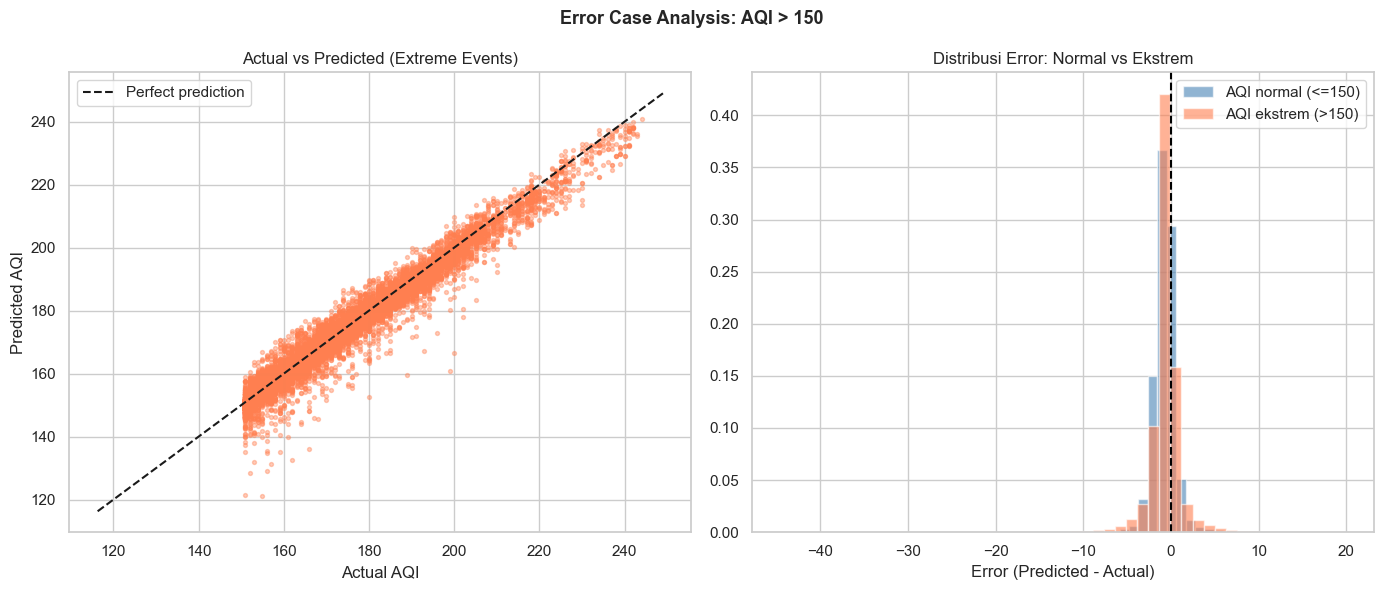


Interpretasi: Model meremehkan AQI ekstrem rata-rata sebesar 0.6 poin AQI.


In [8]:
THRESHOLD = 150

mask_extreme = y_test.values > THRESHOLD
y_ext_true   = y_test.values[mask_extreme]
y_ext_pred   = y_pred_lgb[mask_extreme]
bias_extreme = np.mean(y_ext_pred - y_ext_true)

print(f'Jumlah sampel AQI > {THRESHOLD}: {mask_extreme.sum():,} ({mask_extreme.mean()*100:.1f}% dari test set)')
print(f'Bias pada AQI ekstrem          : {bias_extreme:.2f} '
      f'({"underprediksi" if bias_extreme < 0 else "overprediksi"} rata-rata)')
print(f'MAE pada AQI ekstrem           : {mean_absolute_error(y_ext_true, y_ext_pred):.2f}')
print(f'MAE pada AQI normal (<=150)    : {mean_absolute_error(y_test.values[~mask_extreme], y_pred_lgb[~mask_extreme]):.2f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'Error Case Analysis: AQI > {THRESHOLD}', fontsize=13, fontweight='bold')

axes[0].scatter(y_ext_true, y_ext_pred, alpha=0.4, s=8, color='coral')
lim = [min(y_ext_true.min(), y_ext_pred.min()) - 5,
       max(y_ext_true.max(), y_ext_pred.max()) + 5]
axes[0].plot(lim, lim, 'k--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual AQI'); axes[0].set_ylabel('Predicted AQI')
axes[0].set_title('Actual vs Predicted (Extreme Events)'); axes[0].legend()

err_extreme = y_ext_pred - y_ext_true
err_normal  = y_pred_lgb[~mask_extreme] - y_test.values[~mask_extreme]
axes[1].hist(err_normal,  bins=60, alpha=0.6, color='steelblue', label='AQI normal (<=150)', density=True)
axes[1].hist(err_extreme, bins=40, alpha=0.6, color='coral',     label=f'AQI ekstrem (>{THRESHOLD})', density=True)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_title('Distribusi Error: Normal vs Ekstrem')
axes[1].set_xlabel('Error (Predicted - Actual)'); axes[1].legend()

plt.tight_layout()
plt.savefig('results/plots/extreme_aqi_error_analysis.png', dpi=120)
plt.show()

print(f'\nInterpretasi: Model {"meremehkan" if bias_extreme < 0 else "melebih-lebihkan"} AQI ekstrem '
      f'rata-rata sebesar {abs(bias_extreme):.1f} poin AQI.')

---
## 7. Walk-Forward Cross-Validation

`TimeSeriesSplit` mempartisi data latih menjadi beberapa fold secara kronologis (expanding window), mencegah data future bocor ke training. Ini memberikan estimasi performa yang lebih robust daripada single holdout 80/20.

> **Catatan komputasi:** Setiap fold melatih 1 model LightGBM baru dengan early stopping.

In [9]:
N_SPLITS = 3
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

cv_results = []
print(f'Walk-Forward CV dengan {N_SPLITS} fold...')

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):
    X_tr_cv  = X_train.iloc[tr_idx];  y_tr_cv  = y_train.iloc[tr_idx]
    X_val_cv = X_train.iloc[val_idx]; y_val_cv = y_train.iloc[val_idx]

    cv_model = lgb.LGBMRegressor(
        n_estimators=1000, num_leaves=63, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, min_child_samples=20,
        n_jobs=-1, random_state=42, verbose=-1,
    )
    cv_model.fit(
        X_tr_cv, y_tr_cv,
        eval_set=[(X_val_cv, y_val_cv)],
        callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(0)],
    )

    preds = cv_model.predict(X_val_cv)
    mae   = mean_absolute_error(y_val_cv, preds)
    rmse  = np.sqrt(mean_squared_error(y_val_cv, preds))
    r2    = r2_score(y_val_cv, preds)
    cv_results.append({'Fold': fold+1, 'MAE': mae, 'RMSE': rmse, 'R2': r2,
                        'Train size': len(tr_idx), 'Val size': len(val_idx)})
    print(f'  Fold {fold+1}: MAE={mae:.4f}  RMSE={rmse:.4f}  R2={r2:.4f}')

df_cv = pd.DataFrame(cv_results)
print(f'\nCV MAE : {df_cv["MAE"].mean():.4f} +/- {df_cv["MAE"].std():.4f}')
print(f'CV RMSE: {df_cv["RMSE"].mean():.4f} +/- {df_cv["RMSE"].std():.4f}')
print(f'CV R2  : {df_cv["R2"].mean():.4f} +/- {df_cv["R2"].std():.4f}')
df_cv.to_csv('results/lgb_cv_results.csv', index=False)

Walk-Forward CV dengan 3 fold...


  Fold 1: MAE=6.7839  RMSE=9.5906  R2=0.9477


  Fold 2: MAE=0.8614  RMSE=1.4623  R2=0.9990


  Fold 3: MAE=0.9320  RMSE=1.7334  R2=0.9988

CV MAE : 2.8591 +/- 3.3992
CV RMSE: 4.2621 +/- 4.6166
CV R2  : 0.9818 +/- 0.0295


### Interpretasi Hasil Walk-Forward CV

Hasil CV menunjukkan variabilitas yang signifikan antar fold:

| Fold | Train size | Val size | MAE | RMSE | R² |
|---|---|---|---|---|---|
| Fold 1 | ~209K | ~209K | 6.78 | 9.59 | 0.9477 |
| Fold 2 | ~419K | ~209K | 0.86 | 1.46 | 0.9990 |
| Fold 3 | ~628K | ~209K | 0.93 | 1.73 | 0.9988 |
| **Mean** | — | — | **2.86** | **4.26** | **0.9818** |
| **Std** | — | — | **±3.40** | **±4.62** | **±0.030** |

**Penyebab standar deviasi tinggi (CV coefficient ≈ 119%):**

Fold 1 memiliki performa jauh lebih buruk (MAE = 6.78) karena data latih Fold 1 hanya mencakup ~25% pertama dari training set (sekitar tahun 2000–2006). Pada periode tersebut, data sensor AQI masih terbatas dan polanya berbeda signifikan dengan periode modern. Model yang dilatih pada data era lama tersebut harus memprediksi data 2006–2012 — gap distribusi yang besar.

**Implikasi:** Ini adalah bukti **temporal non-stationarity** — pola AQI Bangladesh berubah secara nyata antar dekade, kemungkinan karena perubahan industrialisasi, pertumbuhan kota, dan perubahan musim monsoon.

**Rekomendasi:**
- Model perlu **re-training periodik** (disarankan setiap 3–6 bulan) untuk mempertahankan akurasi saat kondisi polusi berubah
- Untuk deployment produksi, gunakan **rolling window training** (training hanya N tahun terakhir) daripada expanding window agar model tetap relevan dengan kondisi terkini
- Performa Fold 2 & 3 (MAE ≈ 0.86–0.93) lebih representatif untuk estimasi performa pada data modern

---
## 8. Export Hasil Final & Ringkasan

In [10]:
print('=' * 60)
print('RINGKASAN EVALUASI MODEL — LightGBM AQI Bangladesh')
print('=' * 60)

mae  = mean_absolute_error(y_test, y_pred_lgb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lgb))
r2   = r2_score(y_test, y_pred_lgb)
mape = np.mean(np.abs((y_test - y_pred_lgb) / (np.abs(y_test) + 1e-8))) * 100

print(f'  MAE  : {mae:.4f}')
print(f'  RMSE : {rmse:.4f}')
print(f'  R2   : {r2:.4f}')
print(f'  MAPE : {mape:.4f}%')
print()
print(f'  Best iteration : {lgb_model.best_iteration_}')
print(f'  n_features     : {len(FEATURES)}')
print('=' * 60)

pd.DataFrame([{'Model':'LightGBM','MAE':mae,'RMSE':rmse,'R2':r2,'MAPE':mape}]).to_csv(
    'results/lgb_metrics_summary.csv', index=False
)

RINGKASAN EVALUASI MODEL — LightGBM AQI Bangladesh
  MAE  : 1.1339
  RMSE : 1.7671
  R2   : 0.9986
  MAPE : 1.2914%

  Best iteration : 308
  n_features     : 98
